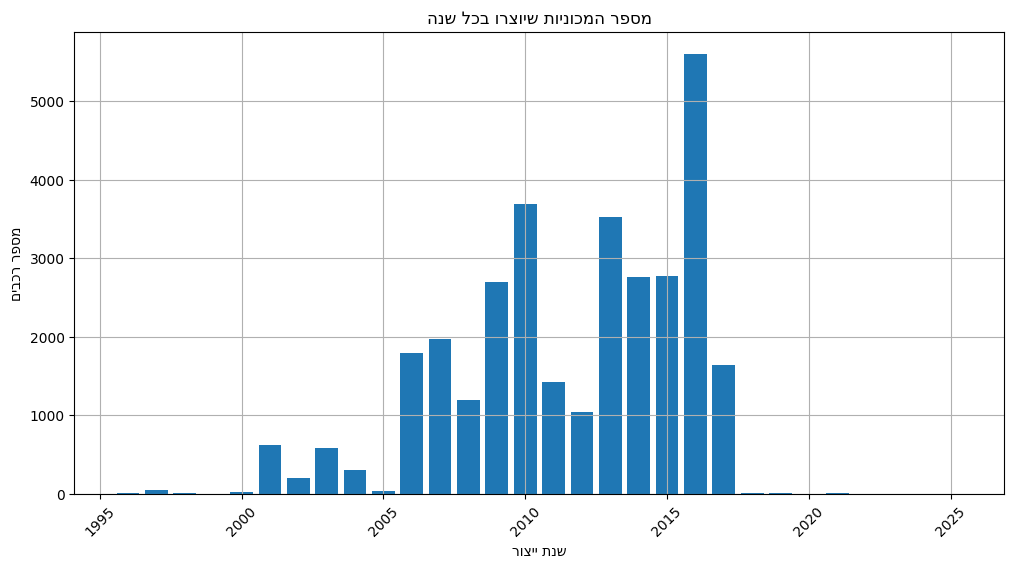

In [3]:
# ===============================
# שלב 1 – טעינת נתונים
# ===============================
import requests
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import Dropdown, VBox, Output

url = 'https://data.gov.il/api/3/action/datastore_search?resource_id=053cea08-09bc-40ec-8f7a-156f0677aff3'

response = requests.get(url)
data = response.json()
data_df = pd.DataFrame(data['result']['records'])

pd.set_option("display.max_columns", None)

# ===============================
# שלב 2 – עיבוד נתונים
# ===============================
stats = data_df.describe()
year_counts = data_df['shnat_yitzur'].value_counts().sort_index()

# ===============================
# TAB 1 – סטטיסטיקה
# ===============================
tab1 = widgets.Output()
with tab1:
    print("📊 סטטיסטיקה כללית")
    display(stats)

# ===============================
# TAB 2 – טבלה
# ===============================
tab2 = widgets.Output()
with tab2:
    print("📋 כל הנתונים")
    display(data_df)

# ===============================
# TAB 3 – גרף
# ===============================
tab3 = widgets.Output()
with tab3:
    print("📈 מספר רכבים לפי שנה")

    plt.figure(figsize=(12,6))
plt.bar(year_counts.index, year_counts.values)

plt.xlabel("שנת ייצור"[::-1])
plt.ylabel("מספר רכבים"[::-1])
plt.title("מספר המכוניות שיוצרו בכל שנה"[::-1])

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# ===============================
# יצירת טאבים
# ===============================
tabs = widgets.Tab(children=[tab1, tab2, tab3])
tabs.set_title(0, "סטטיסטיקה")
tabs.set_title(1, "טבלה")
tabs.set_title(2, "גרף")

display(tabs)

# ===============================
# בונוס – בחירת יצרן ודגם
# ===============================
output_area = Output()

tozeret = Dropdown(
    options=[''] + sorted(data_df['tozeret_nm'].dropna().unique()),
    description='יצרן:'
)

model = Dropdown(
    options=[''],
    description='דגם:'
)

def update_models(change):
    if change['new']:
        filtered = data_df[data_df['tozeret_nm'] == change['new']]
        model.options = [''] + sorted(filtered['kinuy_mishari'].dropna().unique())

def show_data(change):
    output_area.clear_output()
    if tozeret.value and model.value:
        filtered = data_df[
            (data_df['tozeret_nm'] == tozeret.value) &
            (data_df['kinuy_mishari'] == model.value)
        ]
        with output_area:
            print("כמות רכבים:", len(filtered))
            print("רמות גימור:", list(filtered['ramat_gimur'].dropna().unique()))

tozeret.observe(update_models, names='value')
model.observe(show_data, names='value')

display(VBox([tozeret, model, output_area]))